# Tugas Analisis Multimedia: **Image (Citra Digital)**

**Mata Kuliah:** Sistem & Teknologi Multimedia  
**Nama:** Dinda Joycehana  
**NIM:** 122140048 

---

## Deskripsi Tugas

Tugas ini bertujuan untuk memahami **representasi dasar data citra digital (image)** melalui praktik langsung memuat data, visualisasi komponen warna, serta melakukan analisis spasial sederhana menggunakan berbagai teknik dasar pengolahan citra.

Anda akan bekerja dengan satu atau beberapa gambar (foto diri, objek, atau lingkungan sekitar) untuk:

* Mengamati struktur data piksel dan channel warna (RGB, Grayscale, HSV, dsb.)
* Menganalisis perbedaan hasil visualisasi antar representasi warna
* Melakukan eksplorasi sederhana terhadap transformasi citra (cropping, filtering, edge detection, dll.)
* Menyimpulkan pengaruh setiap tahap pemrosesan terhadap persepsi visual

Fokus tugas ini adalah pada **pemahaman konsep representasi spasial citra digital** dan **interpretasi hasil visualisasi**, **bukan** pada manipulasi kompleks atau penerapan model pembelajaran mesin.

### **Soal 1 — Cropping dan Konversi Warna**

* Ambil sebuah gambar diri Anda (*selfie*) menggunakan kamera atau smartphone.
* Lakukan **cropping secara manual** untuk menghasilkan dua potongan:

  * Cropping **kotak persegi pada area wajah**.
  * Cropping **persegi panjang pada area latar belakang**.
* Resize hasil crop menjadi **920×920 piksel**.
* Konversi gambar menjadi **grayscale** dan **HSV**, lalu tampilkan ketiganya berdampingan.
* Tambahkan **anotasi teks** berisi nama Anda di atas kepala pada gambar hasil crop.

  * Gaya teks (font, warna, posisi, ukuran, ketebalan) **dibebaskan**.
* Jelaskan efek **cropping** dan **perubahan warna** menggunakan **Markdown**.


In [1]:
# Import Libraries
import cv2
import numpy as np
from matplotlib import pyplot as plt
import os
import mediapipe as mp


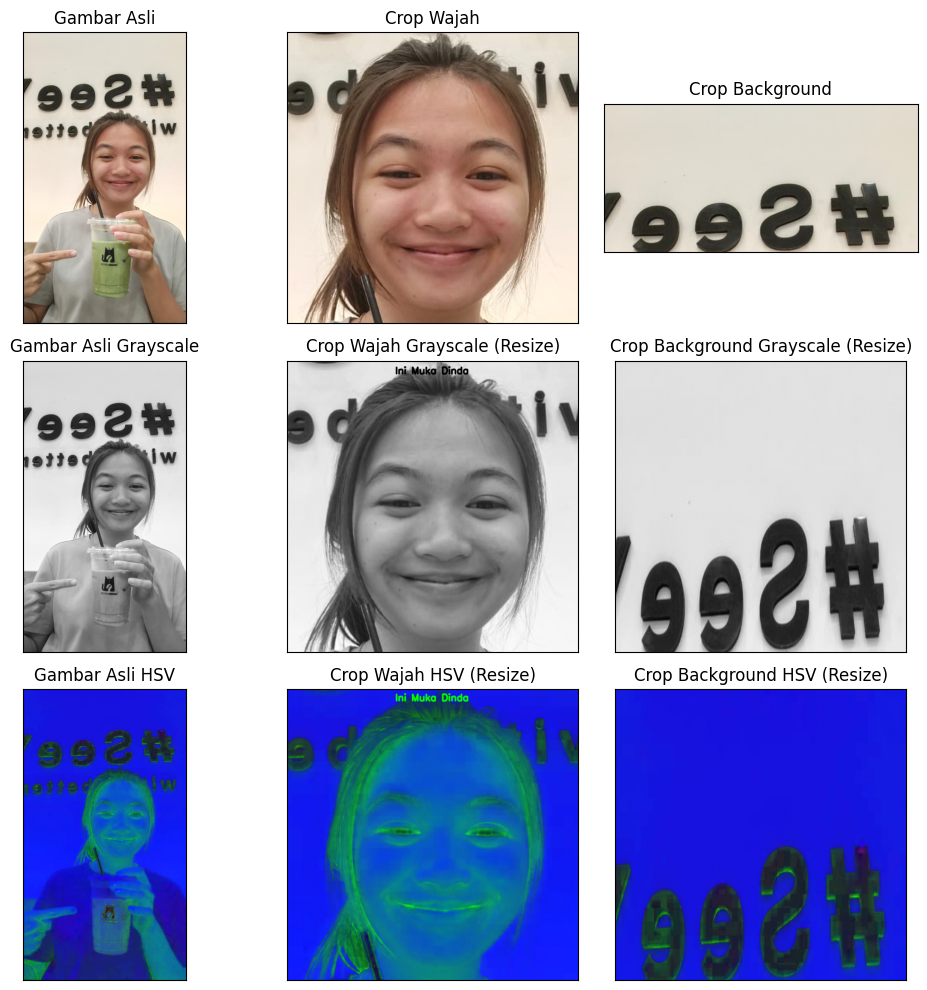

In [2]:
# Load Image with os
image_path = os.path.join('assets_ws4', 'Selfie_full.jpeg')
image1 = cv2.imread(image_path)

#crop image untuk wajah dan persegi panjang untuk background
height, width, _ = image1.shape
image2 = image1[340:770, 200:630]  # Crop wajah persegi dari koordinat x,y min = (200, 340) hingga x,y max =(630, 770)
image3 = image1[0:340, 0:1020]     # Crop Background persegi panjang horizontal dari koordinat x,y min = (0, 0) hingga x,y max =(1020, 340)

# convert BGR to RGB
image1_rgb = cv2.cvtColor(image1, cv2.COLOR_BGR2RGB)
image2_rgb = cv2.cvtColor(image2, cv2.COLOR_BGR2RGB)
image3_rgb = cv2.cvtColor(image3, cv2.COLOR_BGR2RGB)

# Resize Image to 920x920
image2_resize = cv2.resize(image2_rgb, (920, 920))
image3_resize = cv2.resize(image3_rgb, (920, 920))

# convert to grayscale
image1_gray = cv2.cvtColor(image1_rgb, cv2.COLOR_RGB2GRAY)
image2_gray = cv2.cvtColor(image2_resize, cv2.COLOR_RGB2GRAY)
image3_gray = cv2.cvtColor(image3_resize, cv2.COLOR_RGB2GRAY)

# convert to hsv
image1_hsv = cv2.cvtColor(image1_rgb, cv2.COLOR_RGB2HSV)
image2_hsv = cv2.cvtColor(image2_resize, cv2.COLOR_RGB2HSV)
image3_hsv = cv2.cvtColor(image3_resize, cv2.COLOR_RGB2HSV)

# Tambah anotasi pada gambar dengan teks di center atas
font = cv2.FONT_HERSHEY_SIMPLEX
font_scale = 1
thickness = 3
text = 'Ini Muka Dinda'

# Untuk image2_gray
text_size_gray = cv2.getTextSize(text, font, font_scale, thickness)[0]
x_gray = (image2_gray.shape[1] - text_size_gray[0]) // 2 #memposisikan teks di tengah secara horizontal
y_gray = 40 #memposisikan y di 40 piksel dari atas
cv2.putText(image2_gray, text, (x_gray, y_gray), font, font_scale, (0, 0, 255), thickness, cv2.LINE_AA) #font color biru

# Untuk image2_hsv
text_size_hsv = cv2.getTextSize(text, font, font_scale, thickness)[0]
x_hsv = (image2_hsv.shape[1] - text_size_hsv[0]) // 2
y_hsv = 40
cv2.putText(image2_hsv, text, (x_hsv, y_hsv), font, font_scale, (0, 255, 0), thickness, cv2.LINE_AA) #font color hijau

# Display Image  
# Membuat list untuk gambar dan judul dengan arrays  
images = [
    image1_rgb, image2_rgb, image3_rgb,
    image1_gray, image2_gray, image3_gray,
    image1_hsv, image2_hsv, image3_hsv
]

titles = [
    'Gambar Asli', 'Crop Wajah', 'Crop Background',
    'Gambar Asli Grayscale', 'Crop Wajah Grayscale (Resize)', 'Crop Background Grayscale (Resize)',
    'Gambar Asli HSV', 'Crop Wajah HSV (Resize)', 'Crop Background HSV (Resize)'
]

plt.figure(figsize=(10, 10))

for i in range(9):
    plt.subplot(3, 3, i + 1)

    # RGB / HSV
    if i in [0, 1, 2, 6, 7, 8]:
        plt.imshow(images[i])
    # Grayscale
    else:
        plt.imshow(images[i], cmap='gray')

    plt.title(titles[i])
    plt.xticks([])
    plt.yticks([])

plt.tight_layout()
plt.show()




### Penjelasan 

##### Efek Cropping dan resize

Pada visualisasi plot diatas, terlihat perbandingan antara gambar original, crop wajah, dan crop background bahkan hasil resize dari image yang di crop. 

1. Perubahan bentuk panjang dan lebar

Setiap image yang di crop dan di resize, terjadi perubahan panjang dan lebar pada image. Hasilnya gambar juga terlihat semakin melebar dan memanjang. seperti tulisan pada background yang terlihat memanjang keatas.

2. Perubahan warna

Lalu, hasil crop juga memberi perubahan warna pada gambar. Terlihat pada image original, warna wajah crop seperti lebih merah dibandingkan foto asli tanpa crop, begitupun pada background yang lebih /terlihat lebih hitam daripada image yang sudah di crop. 
begitu pula terjadi perubahan warna pada greyscale maupun hsv. Warna pada hasil crop resize terlihat lebih pekat dibandingkan pada foto asli yang tanpa crop.

3. Efek perubahan warna Greyscale dan HSV
- Pada gambar greyscale, gambar berupa bayangan, siluet menjadi lebih pekat dan terlihat. Mempermudah melihat terang gelap secara kontras. Namun jadi tidak bisa melihat detail siku, tekstur tepi, atau bentuknya. Karena hasilnya berfokus pada gelap terangnya gambar.

- HSV (Hue, Saturation, Value) membantu untuk melihat segmentasi warna. Terlihat detail siku/bentuk pada gambar karena dilihat pada perubahan warnanya. Terlihat kepekatan warna juga dari hasil HSV ini. membantu kalau mau mengolah image seperti meningkatkan pencahayaan (brightness) ataupun saturasi awarna.


### **Soal 2 — Manipulasi Channel Warna RGB**

* Gunakan gambar hasil crop dari Soal 1.
* Konversikan gambar ke ruang warna **RGB**.
* Lakukan manipulasi channel warna dengan cara:

  * **Naikkan intensitas channel merah sebanyak 50 poin** (maksimum 255).
  * **Turunkan intensitas channel biru sebanyak 30 poin** (minimum 0).
* Teknik atau cara menaikkan/menurunkan intensitas **dibebaskan**, asalkan logis dan hasilnya terlihat.
* Gabungkan kembali channel warna dan **simpan gambar hasil modifikasi dalam format `.png`**.
* **Tampilkan histogram per channel (R, G, B)** untuk gambar asli dan hasil modifikasi menggunakan `matplotlib.pyplot.hist`.
* Jelaskan dampak perubahan RGB pada warna gambar dalam sel **Markdown**.


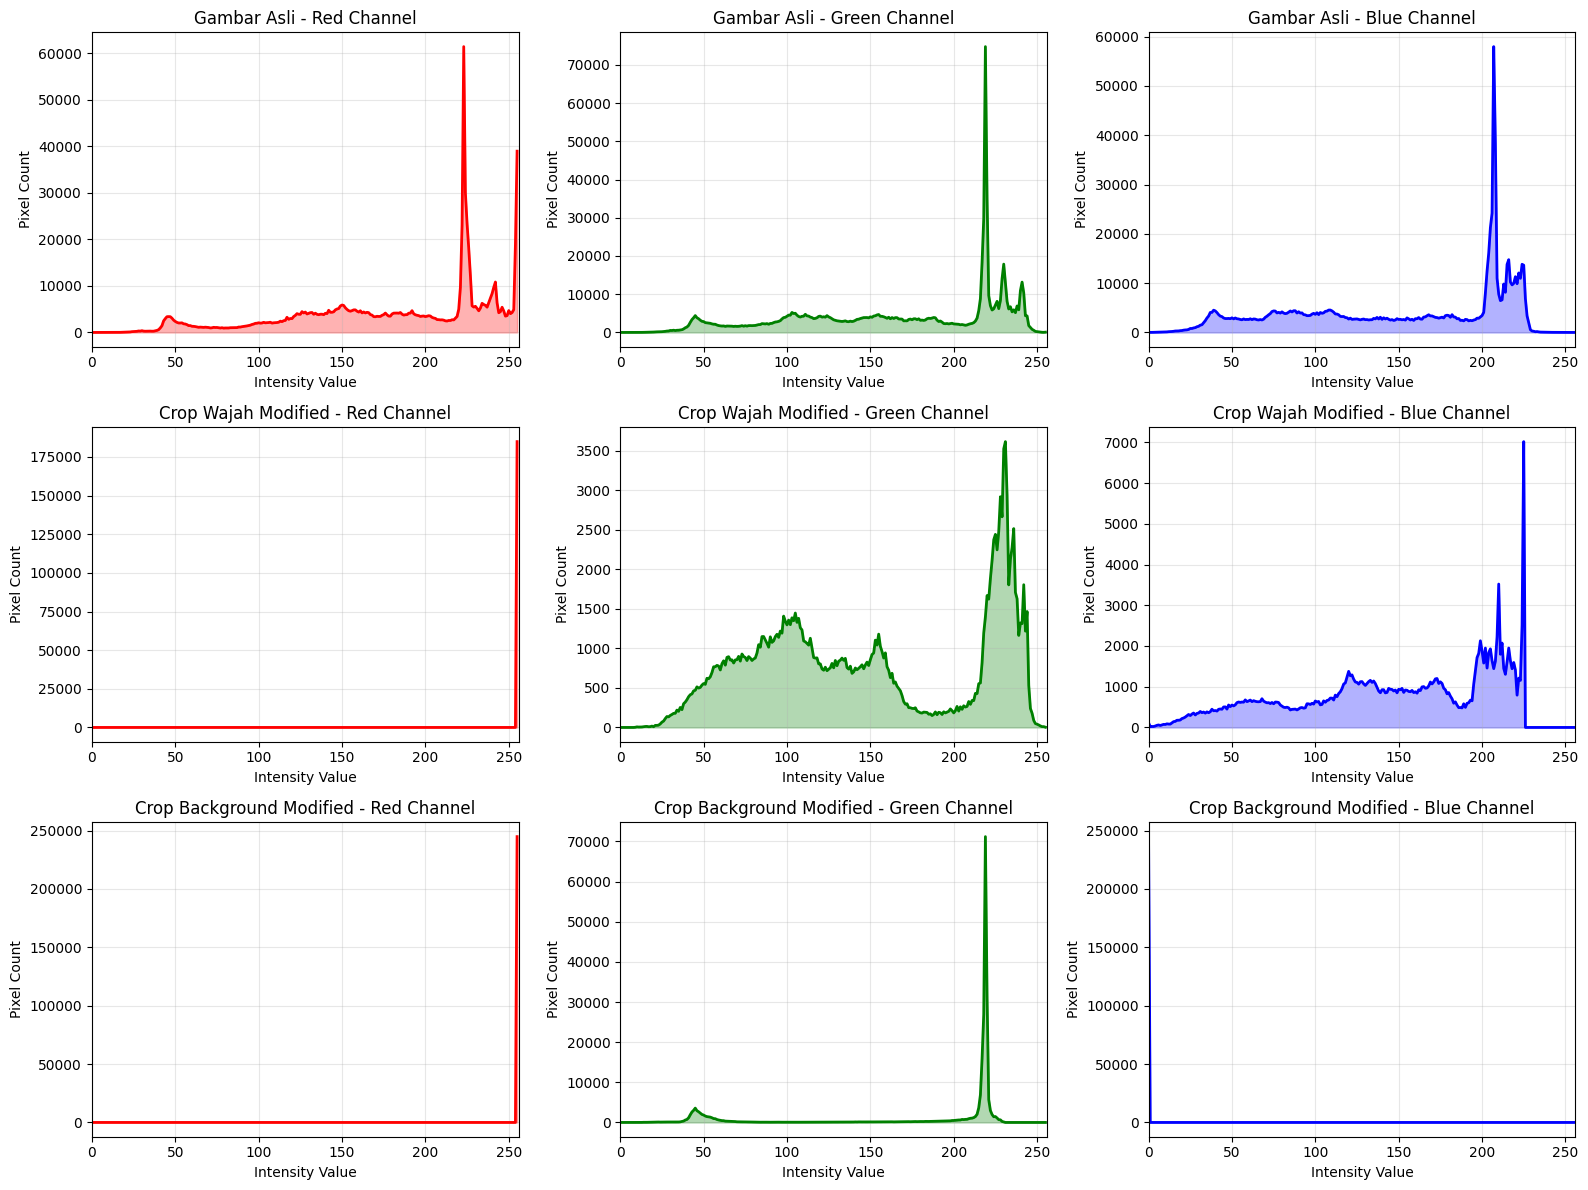

In [16]:
#sebelumnya sudah mengkonversi image ke RGB pada soal 1
# Menaikkan intensitas warna merah pada image2_rgb
red_channel = image2_rgb[:, :, 0] # Mengakses channel merah
red_channel = cv2.add(red_channel, 50)  # Menambahkan nilai 50 pada channel merah
image2_rgb[:, :, 0] = red_channel # Memperbarui channel merah pada image2_rgb

# Menurunkan intensitas warna biru pada image2_rgb
blue_channel = image2[:, :, 2] # Mengakses channel biru
blue_channel = cv2.subtract(blue_channel, 30)  # Mengurangi nilai 30 pada channel biru
image2_rgb[:, :, 2] = blue_channel # Memperbarui channel biru pada image2_rgb

# Menaikkan intensitas warna merah pada image3_rgb
red_channel_bg = image3_rgb[:, :, 0] # Mengakses channel merah
red_channel_bg = cv2.add(red_channel_bg, 50)  # Menambahkan nilai 50 pada channel merah
image3_rgb[:, :, 0] = red_channel_bg # Memperbarui channel merah pada image3_rgb

# Menurunkan intensitas warna biru pada image3_rgb
blue_channel_bg = image3_rgb[:, :, 2] # Mengakses channel biru
blue_channel_bg = cv2.subtract(blue_channel_bg, 30)  # Mengurangi nilai 30 pada channel biru
image3_rgb[:, :, 2] = blue_channel_bg  #Memperbarui channel biru pada image3_rgb

#karena cv2.imwrite menyimpan dalam format BGR, maka
#convert kembali ke BGR untuk disimpan
image2_bgr = cv2.cvtColor(image2_rgb, cv2.COLOR_RGB2BGR)
image3_bgr = cv2.cvtColor(image3_rgb, cv2.COLOR_RGB2BGR)

# Simpan image ke .png
cv2.imwrite(os.path.join('results_ws', 'image2_modified.png'), image2_bgr)
cv2.imwrite(os.path.join('results_ws4', 'image3_modified.png'), image3_bgr)

# Tampilkan histogram per channel dari gambar asli dan hasil modifikasi warna
images_to_plot = [image1_rgb, image2_rgb, image3_rgb]
titles_to_plot = ['Gambar Asli', 'Crop Wajah Modified', 'Crop Background Modified']
colors = ('r', 'g', 'b')
channel_names = ['Red Channel', 'Green Channel', 'Blue Channel']

plt.figure(figsize=(16, 12))

for i in range(3):
    for j, color in enumerate(colors):
        plt.subplot(3, 3, i * 3 + j + 1)
        hist = cv2.calcHist([images_to_plot[i]], [j], None, [256], [0, 256])
        plt.plot(hist, color=color, linewidth=2)
        plt.fill_between(range(256), hist.flatten(), alpha=0.3, color=color)
        plt.xlim([0, 256])
        plt.title(f'{titles_to_plot[i]} - {channel_names[j]}')
        plt.xlabel('Intensity Value')
        plt.ylabel('Pixel Count')
        plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Penjelasan

1. Gambar Original

Pada histogram gambar original, terlihat penyebaran warna RGB yang cukup merata pada intensitas 50-250.

2. Gambar crop wajah

Histogram pada gambar crop wajah menunjukkan warna merah berada di titik maksimum yaitu 255. Dan warna hijau dan biru juga meningkat tinggi. Hal ini menghasilkan gambar yang berwarna campuran kuning, hijau, keunguan

3. Gambar crop background

Terlihat warna merah juga berada di titik maksimum 255. Sedangkan hijau terdapat 2 pucak tertinggi yaitu pada intensitas 50 dan 210-220. Artinya ini hijau lumayan terang dan ada hijau redup pada sebagian kecil area. Selain itu warna biru malah hampir 0, artinya warna biru paling minim kontribusi. Hasil ini memberikan warna gamber kuning-keorenan karena warna merah dan hijau yang tinggi.

### **Soal 3 — Deteksi Tepi dan Filter Citra**

* Ambil gambar **objek dengan background bertekstur** (misalnya kain bermotif, jerami, atau batu).
* Terapkan **edge detection (Canny)** dan tampilkan hasilnya.
* Lakukan **thresholding dengan nilai ambang tertentu** (bebas Anda tentukan) agar hanya objek utama yang tersisa.
* Buat **bounding box** di sekitar objek hasil segmentasi (boleh manual atau otomatis).
* Terapkan **filter blur** dan **filter sharpening**, lalu **bandingkan hasil keduanya**.
* Jelaskan bagaimana setiap filter memengaruhi detail gambar dalam format **Markdown**.


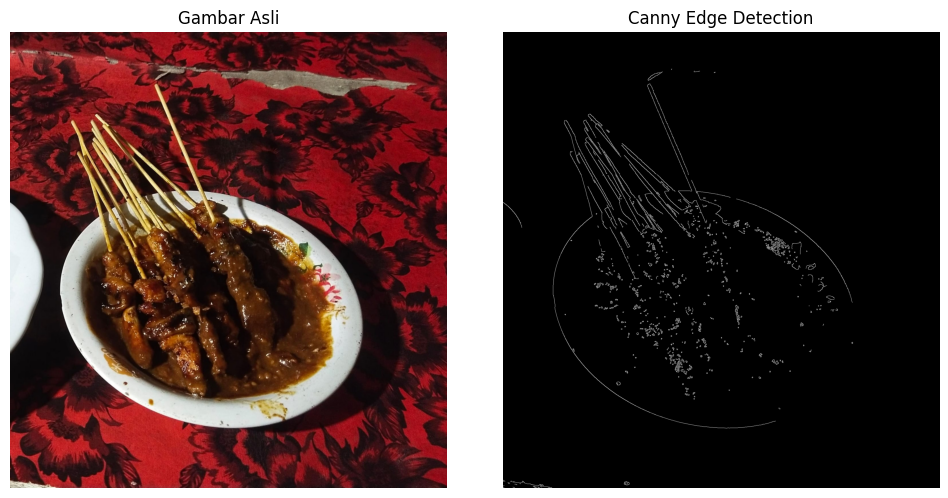

In [4]:
# load image
image_path = os.path.join('assets_ws4', 'gambar_motif.jpeg')
foto_motif = cv2.imread(image_path)

# convert to grayscale
gray = cv2.cvtColor(foto_motif, cv2.COLOR_BGR2GRAY)

# Menerapkan canny edge detection pada foto_motif
edges = cv2.Canny(gray, 280, 550) #tentukan thresholding untuk menemukan tepi pada gambar

# display hasilnya
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)    
plt.title('Gambar Asli')
plt.imshow(cv2.cvtColor(foto_motif, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.subplot(1, 2, 2)
plt.title('Canny Edge Detection')
plt.imshow(edges, cmap='gray')
plt.axis('off')
plt.tight_layout()
# mask bernilai 0 (background) dan 255 (foreground)
mask = cv2.imread("mask.png", 0)
plt.show()

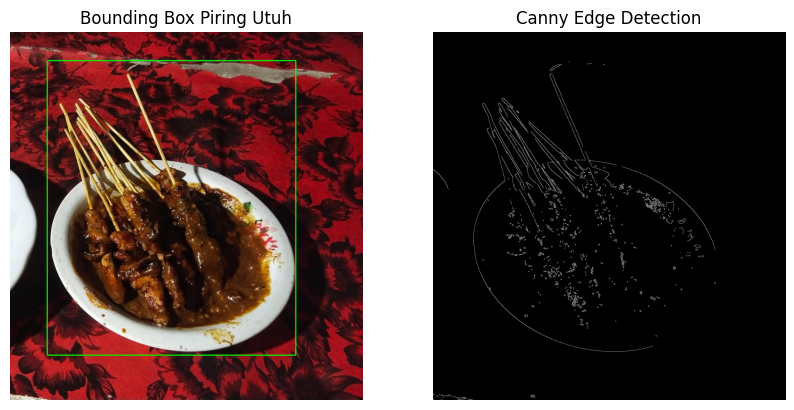

In [5]:
#Membuat bounding box di sekitar piring utuh pada foto_motif
# 1. Perbesar / sambungkan garis tepi agar menjadi satu objek besar
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
dilated = cv2.dilate(edges, kernel, iterations=2)

# buat bounding box di sekitar tepi yang terdeteksi
contours, _ = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
cnt = max(contours, key=cv2.contourArea)  # menemukan kontur terbesar

x, y, w, h = cv2.boundingRect(cnt)
cv2.rectangle(foto_motif, (x, y), (x + w, y + h), (0, 255, 0), 3)  # menggambar bounding box berwarna hijau

# 4. Tampilkan hasil bounding box dengan canny edge detection
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title("Bounding Box Piring Utuh")
plt.imshow(cv2.cvtColor(foto_motif, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Canny Edge Detection")
plt.imshow(edges, cmap="gray")
plt.axis("off")
plt.show()

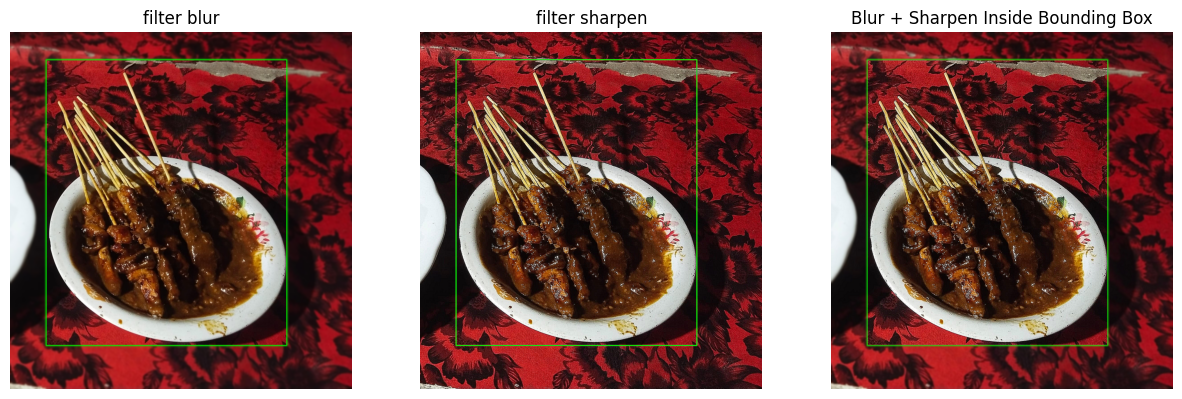

In [6]:
# filter blur pada area di luar bounding box
blurred_image = cv2.GaussianBlur(foto_motif, (21, 21), 0)
mask = np.zeros(foto_motif.shape[:2], dtype="uint8")
cv2.rectangle(mask, (x, y), (x + w, y + h), 255, -1)  # area dalam bounding box bernilai 255
masked_blur = cv2.bitwise_and(blurred_image, blurred_image, mask=cv2.bitwise_not(mask))
masked_original = cv2.bitwise_and(foto_motif, foto_motif, mask=mask)
final_image = cv2.add(masked_blur, masked_original)

#filter sharpen pada area dalam bounding box
kernel_sharpening = np.array([[-1, -1, -1], 
                              [-1, 9, -1],
                              [-1, -1, -1]])
sharpened = cv2.filter2D(foto_motif, -1, kernel_sharpening)

#filter blur + sharpen
blur_sharpened = cv2.filter2D(final_image, -1, kernel_sharpening)

# Tampilkan hasil perbandingan ketiganya
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.title("filter blur")
plt.imshow(cv2.cvtColor(final_image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.subplot(1, 3, 2)
plt.title("filter sharpen")
plt.imshow(cv2.cvtColor(sharpened, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.subplot(1, 3, 3)
plt.title("Blur + Sharpen Inside Bounding Box")
plt.imshow(cv2.cvtColor(blur_sharpened, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()


### Penjelasan

1. Filter blur 

Filter blur memberikan kesan untuk fokus ke dalam bounding box. Karena background motif jadi terlihat samar. Mata kita akan mengabaikan sisi yang samar dan berfokus pada yang lebih jelas

2. Filter Sharpening

Filter sharpen memberikan tingkat kejelasan dan kontras gambar yang lebih baik dalam bounding box daripada original. Namun tidak terlalu terlihat jauh berbeda hasil sharpening dengan yang ori. Sehingga mata tetap kurang berfokus pada hasil image dalam bounding box walaupun sudah di sharpen

3. Combine Blur + Sharpening

Hasil penggabungan kedua filter ini memberi hasil lebih optimal dimana mata akan mengesampingkan background yang samar/blur. Dan mampu melihat gambar dalam bounding box dengan lebih jelas dan detail karena telah di tajamkan (sharpen).

### **Soal 4 — Deteksi Wajah dan Filter Digital Kreatif**

* Ambil gambar diri Anda dengan ekspresi wajah **netral**.
* Lakukan **deteksi wajah dan landmark** menggunakan salah satu dari:

  * **MediaPipe**, atau
  * **Dlib**, atau
  * **OpenCV**.
* Buat **overlay filter digital kreatif** karya Anda sendiri, misalnya:

  * topi, kumis, masker, helm, aksesoris, atau bentuk unik lainnya.
  * Filter boleh dibuat dari **gambar eksternal (PNG)** *atau* digambar langsung (misal bentuk lingkaran, garis, poligon, dll).
* Pastikan posisi overlay menyesuaikan **landmark wajah** dengan logis.
* **Gunakan alpha blending sebagai saran** agar hasil tampak lebih natural.
* Tampilkan perbandingan antara **gambar asli** dan **hasil dengan filter**.
* Jelaskan bagaimana Anda menghitung posisi overlay dan tantangan yang dihadapi selama implementasi (gunakan **Markdown**).

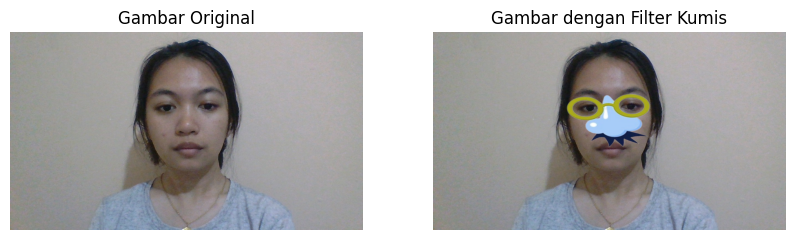

In [7]:
import cv2
import numpy as np
import mediapipe as mp
import os
import matplotlib.pyplot as plt

# Load image
face_path = os.path.join("assets_ws4", "gambar_netral.jpg")
kumis_path = os.path.join("assets_ws4", "kumis_removebg.png")

face_img = cv2.imread(face_path)
face_img = cv2.cvtColor(face_img, cv2.COLOR_BGR2RGB) #convert BGR to RGB

kumis = cv2.imread(kumis_path, cv2.IMREAD_UNCHANGED)

# Inisialisasi Mediapipe Face Mesh
mp_face_mesh = mp.solutions.face_mesh

# Fungsi untuk overlay gambar dengan alpha channel
def overlay_image(bg, fg, x, y):
    fh, fw = fg.shape[:2] # Mendapatkan tinggi dan lebar foreground
    if x < 0 or y < 0 or x+fw > bg.shape[1] or y+fh > bg.shape[0]:
        return bg
    
    #alpha blending
    overlay = fg[:, :, :3] 
    mask = fg[:, :, 3:] / 255.0 
     
    roi = bg[y:y+fh, x:x+fw]
    blended = (1 - mask) * roi + mask * overlay
    bg[y:y+fh, x:x+fw] = blended.astype(np.uint8)

    return bg

with mp_face_mesh.FaceMesh(
    static_image_mode=True,
    refine_landmarks=True,
    max_num_faces=1
) as fm:

    h, w, _ = face_img.shape
    result = fm.process(face_img)

    if not result.multi_face_landmarks:
        print("Tidak ada wajah")
        exit()

    lm = result.multi_face_landmarks[0]

    left = lm.landmark[33]
    right = lm.landmark[263]

    x1, y1 = int(left.x * w), int(left.y * h)
    x2, y2 = int(right.x * w), int(right.y * h)

    eye_width = int(np.hypot(x2 - x1, y2 - y1))
    target_w = int(eye_width * 2.2)
    height_scale = 0.8 #aturan skala tinggi kumis

    new_w = target_w
    new_h = int(kumis.shape[0] * height_scale)

    resized = cv2.resize(kumis, (new_w, new_h), interpolation=cv2.INTER_AREA)

    # Pisahkan RGB & alpha
    fg_rgb = resized[:, :, :3]
    fg_alpha = resized[:, :, 3]

    angle = np.degrees(np.arctan2(y2 - y1, x2 - x1))
    M = cv2.getRotationMatrix2D((new_w // 2, new_h // 2), angle, 1.15) #atur skala rotasi kumis

    rot_rgb = cv2.warpAffine(fg_rgb, M, (new_w, new_h))
    rot_alpha = cv2.warpAffine(fg_alpha, M, (new_w, new_h))

    rotated = np.dstack([rot_rgb, rot_alpha])

    cx = (x1 + x2) // 2
    cy = (y1 + y2) // 2

    x_offset = cx - new_w // 2 + 25
    y_offset = cy - new_h // 2 + 70  # sesuaikan posisi vertikal kumis

    output = overlay_image(face_img.copy(), rotated, x_offset, y_offset)

# Display perbandingan gambar original dan hasil filter kumis
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Gambar Original")
plt.imshow(face_img)
plt.axis("off")
plt.subplot(1, 2, 2)
plt.title("Gambar dengan Filter Kumis")
plt.imshow(output)
plt.axis("off")
plt.show()      



### Penjelasan

1. Cara Overlay

Overlay dilakukan dengan berdasarkan titik-titik landmarking pada mata kanan dan kiri. Lebar mata diukur dari jarak antara kedua titik tersebut. Image kacamata diatur menggunakan height_scale (tingggi) dan target_w (lebar). Kemudian dilakukan rotate image kacamata menggunakan getrotationmatrix agar posisinya menyesuaikan posisi mata, hidung, dan mulut. 

Saya pribadi memposisikannya overlay dengan coba-coba. Perbesar perkecil ukuran kacamata dan menyesuaikan angle dengan rotasi.

2. Tantangannya 

Mengatur tinggi, lebar, dan rotasi gambar kumis agar sesuai posisi dan pas di wajah serta terlihat natural. Hasil yang saya buat belum sempurna, apalagi bagian kumis.


### **Soal 5 — Perspektif dan Peningkatan Kualitas Citra**

* Ambil gambar **objek datar** seperti karya tangan di kertas, tulisan di papan tulis, atau foto produk di meja dengan kondisi pencahayaan atau sudut yang tidak ideal.
* Lakukan **preprocessing** untuk memperbaiki tampilan agar lebih rapi dan jelas, dengan langkah-langkah:

  * Konversi ke **grayscale**.
  * **Koreksi perspektif (transformasi homografi)** menggunakan **4 titik manual** agar objek terlihat sejajar dan tidak terdistorsi.
  * Terapkan **thresholding adaptif atau Otsu** (pilih salah satu, dan jelaskan alasan pilihan Anda).
* Tampilkan **setiap tahap pemrosesan dalam satu grid** agar mudah dibandingkan.
* Jelaskan fungsi masing-masing tahap dan bagaimana teknik ini meningkatkan kualitas visual citra (gunakan **Markdown**).

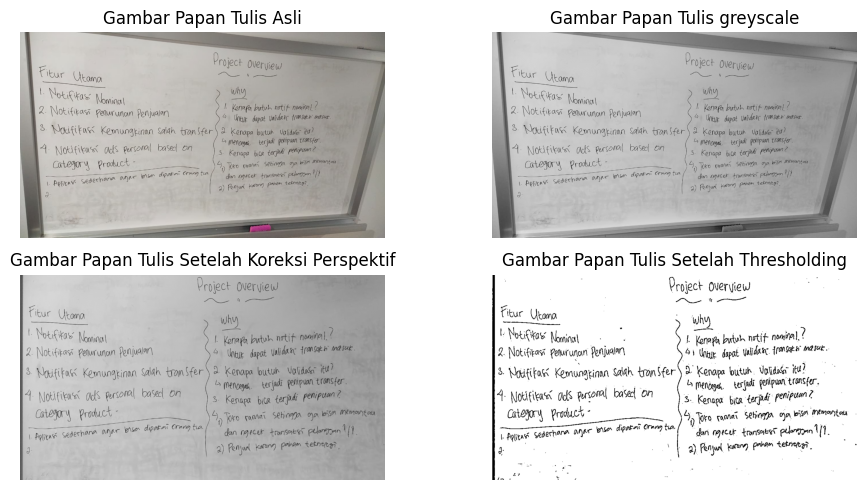

In [8]:
# load image
image_path = os.path.join("assets_ws4", "papan_tulis.jpeg")
papan_tulis = cv2.imread(image_path)
papan_tulis = cv2.cvtColor(papan_tulis, cv2.COLOR_BGR2RGB) #convert BGR to RGB

#preprocessing image papan_tulis
#convert to grayscale
papan_tulis_gray = cv2.cvtColor(papan_tulis, cv2.COLOR_RGB2GRAY)

#koreksi perspektif homografi
pts1 = np.float32([[20, 0], [1200, 110], [70, 650], [1100, 600]])
pts2 = np.float32([[0, 0], [1280, 0], [0, 720], [1280, 720]])
M = cv2.getPerspectiveTransform(pts1, pts2)
papan_tulis_warped = cv2.warpPerspective(papan_tulis_gray, M, (1280, 720))

#thresholding adaptif agar tulisan lebih jelas
papan_tulis_thresh = cv2.adaptiveThreshold(papan_tulis_warped, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 35, 7)   

#menampilkan hasil setiap tahap preprocessing papan tulis
plt.figure(figsize=(10, 5))
plt.subplot(2, 2, 1)
plt.title("Gambar Papan Tulis Asli")
plt.imshow(papan_tulis)
plt.axis("off")
plt.subplot(2, 2, 2)
plt.title("Gambar Papan Tulis greyscale")
plt.imshow(papan_tulis_gray, cmap='gray')
plt.axis("off")
plt.subplot(2, 2, 3)
plt.title("Gambar Papan Tulis Setelah Koreksi Perspektif")  
plt.imshow(papan_tulis_warped, cmap='gray')
plt.axis("off")
plt.subplot(2, 2, 4)
plt.title("Gambar Papan Tulis Setelah Thresholding")
plt.imshow(papan_tulis_thresh, cmap='gray')
plt.axis("off")
plt.tight_layout()
plt.show()




### Penjelasan

1. Greyscale

Greyscale membantu untuk menunjukkan kontras gelap terang pada gambar. Sehingga mempermudah kita untuk menentukan titik-titik yang akan dijadikan patokan gambar

2. Koreksi Perspektif 

Menetapkan titik-titik sudut gambar yang akan diambil. pts1 adalah titik-titik koordinat sudut gambar yang mau kita ambil untuk di proses. sedangkan pts2 adalah titik-titik koordinat sudut gambar posisi titik pts1 akan ditempatkan. Sehingga pts1 akan menyesuaikan posisi titik koordinat pada pts2. Akan terjadi pemanjangan (penarikan) ataupun pemendekan gambar agar hasilnya dari miring menjadi lurus.

3. Thresholding adaptive

Mengubah gambar grayscale menjadi gambar biner secara adaptif, otomatis untuk setiap area gambar. Tujuannya untuk memberikan kontras pada pencahayaan gambar, khusunya warna-warana yang tidak merata. karena gambar akan diubah ke format biner yang hanya nilai 0 dan 1. Efeknya, tulisan pada papan tulis akan terbaca lebih jelas karena latar papan tulis akan menjadi putih dan hanya tulisan gelap yang menjadi hitam. 

# CREDIT

Semua kode dibantu menggunakan copilot dari VSCode dan GPT. Tidak dapat memberikan bukti menggunakan copilot karena auto generate setelah menuliskan comment pada code. 

[Chat GPT](https://chatgpt.com/share/691b3ec4-0354-8008-b158-4c6aa74dbb70)

#### LINK GITHUB REPO

[repository github](https://github.com/dindajoycehana/MULTIMEDIA)

### **Aturan Umum Pengerjaan**

* Kerjakan secara **mandiri**.
* Bantuan AI (seperti ChatGPT, Copilot, dsb.) diperbolehkan **dengan bukti percakapan** (screenshot / link / script percakapan).
* Source code antar mahasiswa harus berbeda.
* Jika mendapat bantuan teman, tuliskan nama dan NIM teman yang membantu.
* Plagiarisme akan dikenakan sanksi sesuai aturan akademik ITERA.
* Cantumkan seluruh **credit dan referensi** yang digunakan di bagian akhir notebook.
* Penjelasan setiap soal ditulis dalam **Markdown**, bukan di dalam komentar kode.

---

### **Aturan Pengumpulan**

* Semua file kerja Anda (notebook `.ipynb`, gambar, dan hasil) **wajib diunggah ke GitHub repository tugas sebelumnya**.

  * Gunakan struktur folder berikut di dalam repo Anda:

    ```
    /Nama_NIM_Repo/ # Nama repo sebelumnya
      ├── assets_ws4/     # berisi semua gambar atau video asli (input)
      ├── results_ws4/    # berisi semua hasil modifikasi dan output
      ├── worksheet4.ipynb
      └── NIM_Worksheet4.pdf
    ```
* File yang dikumpulkan ke **Tally** hanya berupa **hasil PDF** dari notebook Anda, dengan format nama:

  ```
  NIM_Worksheet4.pdf
  ```
* Pastikan notebook telah dijalankan penuh sebelum diekspor ke PDF.
* Sertakan tautan ke repository GitHub Anda di bagian atas notebook atau di halaman pertama PDF.

---

### ✅ **Catatan Akhir**

> Worksheet 4 ini bertujuan mengasah pemahaman Anda tentang manipulasi citra digital secara praktis. Gunakan kreativitas Anda untuk menghasilkan hasil visual yang menarik dan penjelasan konseptual yang jelas.